# Basics of Monte Carlo

This notebook demonstrates the basic principles of Monte Carlo simulations, with examples presented for intuition.

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import timeit

In [151]:
plt.rcParams.update({
        'axes.grid': False,
        'axes.labelsize': 12,
        'axes.linewidth': 0.8,
        'axes.titlesize': 12,
        'font.size': 10,
        'legend.fontsize': 12,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'font.family': 'serif',
        'font.sans-serif': ['Bitstream Vera Sans'],
        'font.serif': ['Times New Roman'],
        'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
        'text.usetex': True,
        'patch.force_edgecolor': True,
        'figure.dpi': 100,
        'savefig.dpi': 100,
    }
)

For reproducibility, let's set the seed of the random number generator

In [152]:
np.random.seed(12) 

## 1. Approximating $\pi$ 

The canonical example to demonstrate Monte Carlo simulations is to approximate $\pi$.

Let's consider a unit square, overlaid with the upper right quadrant of a unit circle. The areas of each are as follow:

\begin{align}
A_\mathrm{square} &= 1 \\
A_\mathrm{circle} &= \pi/4
\end{align}

Since we are interested in one quadrant of this circle, the area is a quarter of the full circle. Now, note that

\begin{align}
\frac{A_\mathrm{Circle}}{A_\mathrm{Square}} = \frac{\pi}{4}
\end{align}

Therefore, we can approximate this ratio by randomly sampling points in the unit square, i.e. $ (X, Y) \sim \mathcal{U}(0,1) \times \mathcal{U}(0,1) $, and taking the ratio $n_\mathrm{in}/n_\mathrm{total}$, where $n_\mathrm{in}$ is the number of points inside the circle and $n_\mathrm{total}$ is the total number of points sampled:

\begin{align}
    \pi \approx 4\frac{n_\mathrm{in}}{n_\mathrm{total}}
\end{align}

Of course, trying to determine $\pi$ this way will never give us the correct answer since $\pi$ is irrational. However, we are only interested in an approximation.

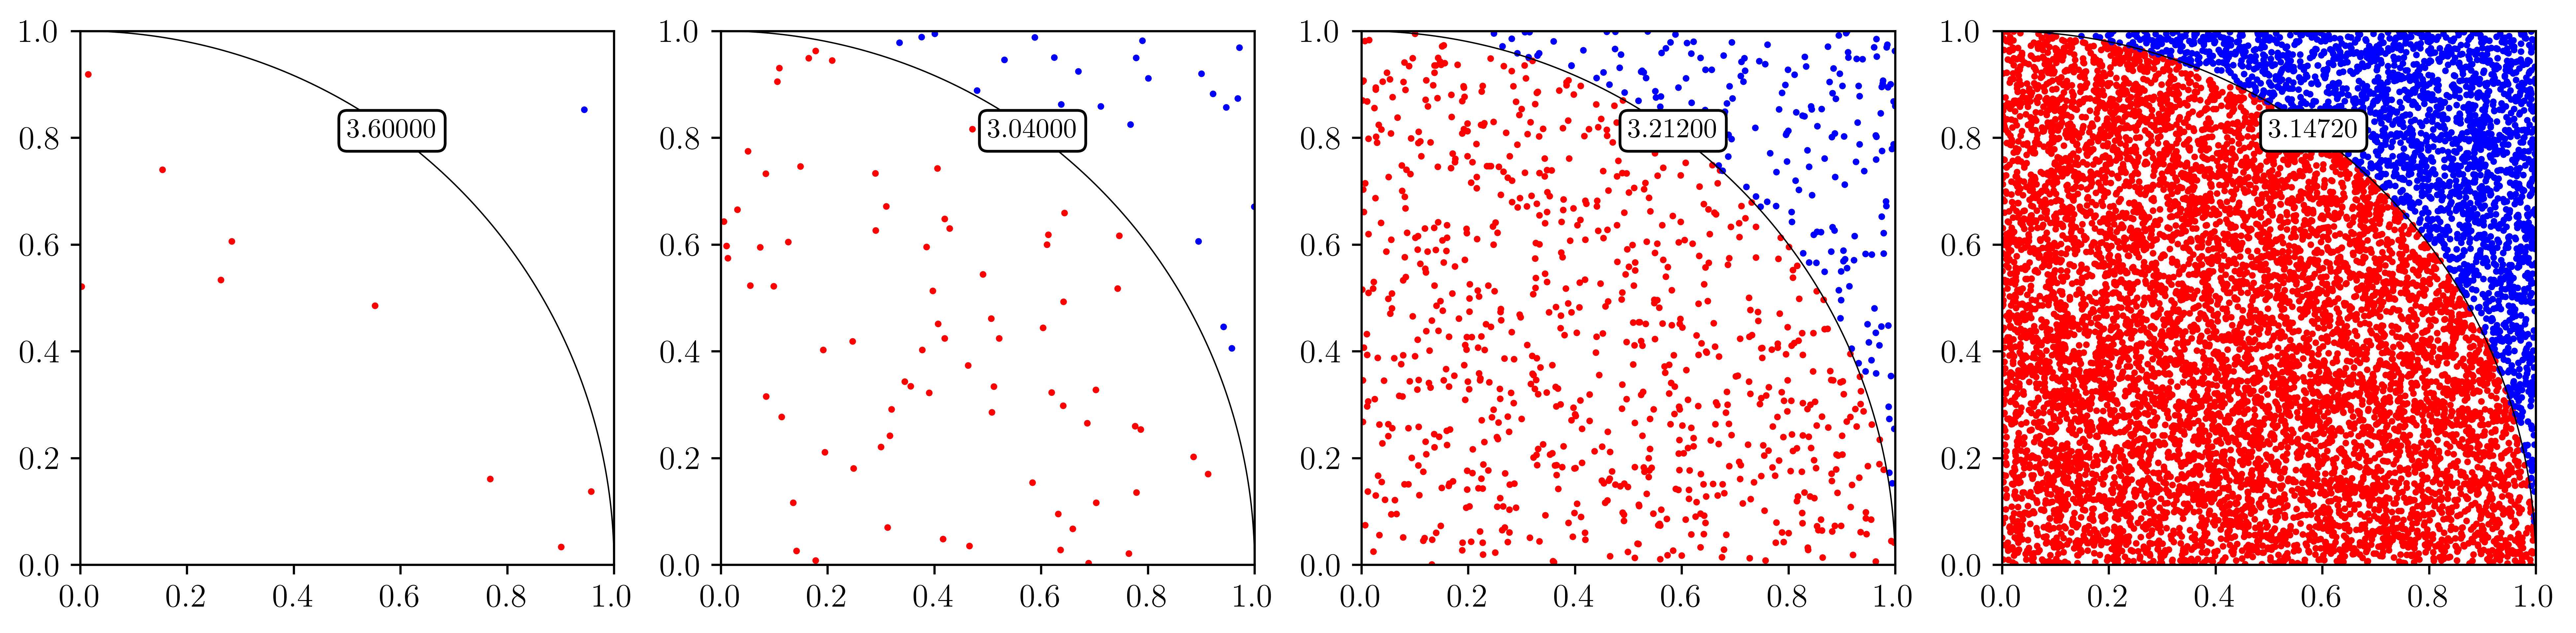

In [153]:
max_iters = 4
iters = np.logspace(1, max_iters, num=max_iters)

fig, ax = plt.subplots(1, max_iters, figsize=(16, 4), dpi=600)

theta = np.linspace(0, np.pi/2, 1000)

results = []

for j in range(max_iters):

    # Reset counters if you want each subplot independent
    i = 0
    o = 0

    # Unit circle
    ax[j].set_aspect('equal')
    ax[j].plot(np.cos(theta), np.sin(theta), linewidth=0.5, color='k')
    ax[j].set_xlim(0, 1)
    ax[j].set_ylim(0, 1)

    # Generate random points
    pts = np.random.rand(int(iters[j]), 2)

    # Vectorised radius test
    r = np.sum(pts**2, axis=1)
    inside_mask = r <= 1
    outside_mask = ~inside_mask

    # Count points
    i = np.sum(inside_mask)
    o = np.sum(outside_mask)

    # Plot in two batches (much faster than point-by-point)
    ax[j].scatter(pts[inside_mask, 0], pts[inside_mask, 1], c='r', s=2)
    ax[j].scatter(pts[outside_mask, 0], pts[outside_mask, 1], c='b', s=2)

    # Estimate pi
    result = 4 * i / (i + o)
    results.append([j, result])

    ax[j].text(
        0.5, 0.8, f"{result:.5f}",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black")
    )

Let's now see how the accuracy of our result changes as we increase the number of samples

(1.0, 5.0)

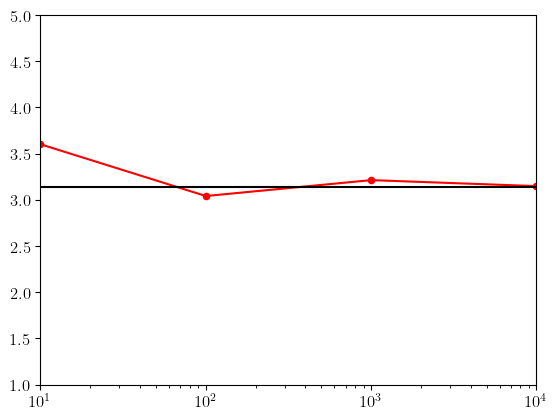

In [154]:
xs = [10**(j[0]+1) for j in results]
ys = [j[1] for j in results]

plt.scatter(xs, ys, s=20, c='r')
plt.plot(xs, ys, c='r')

# Real value of pi
x = np.linspace(10,10**(max_iters),1000)
y = np.linspace(np.pi, np.pi, 1000)
plt.plot(x,y, c='k')

plt.xscale("log")
plt.xlim(10,10000)
plt.ylim(1,5)

Clearly, as we increase the number of samples used we converge to the correct answer. However, this is a stochastoc process, so we can't guarantee that increasing the number of samples increases the accuracy. To see this, let's temporarily change the seed of our random number generator and re-do the above calculation.

In [155]:
np.random.seed(100) 

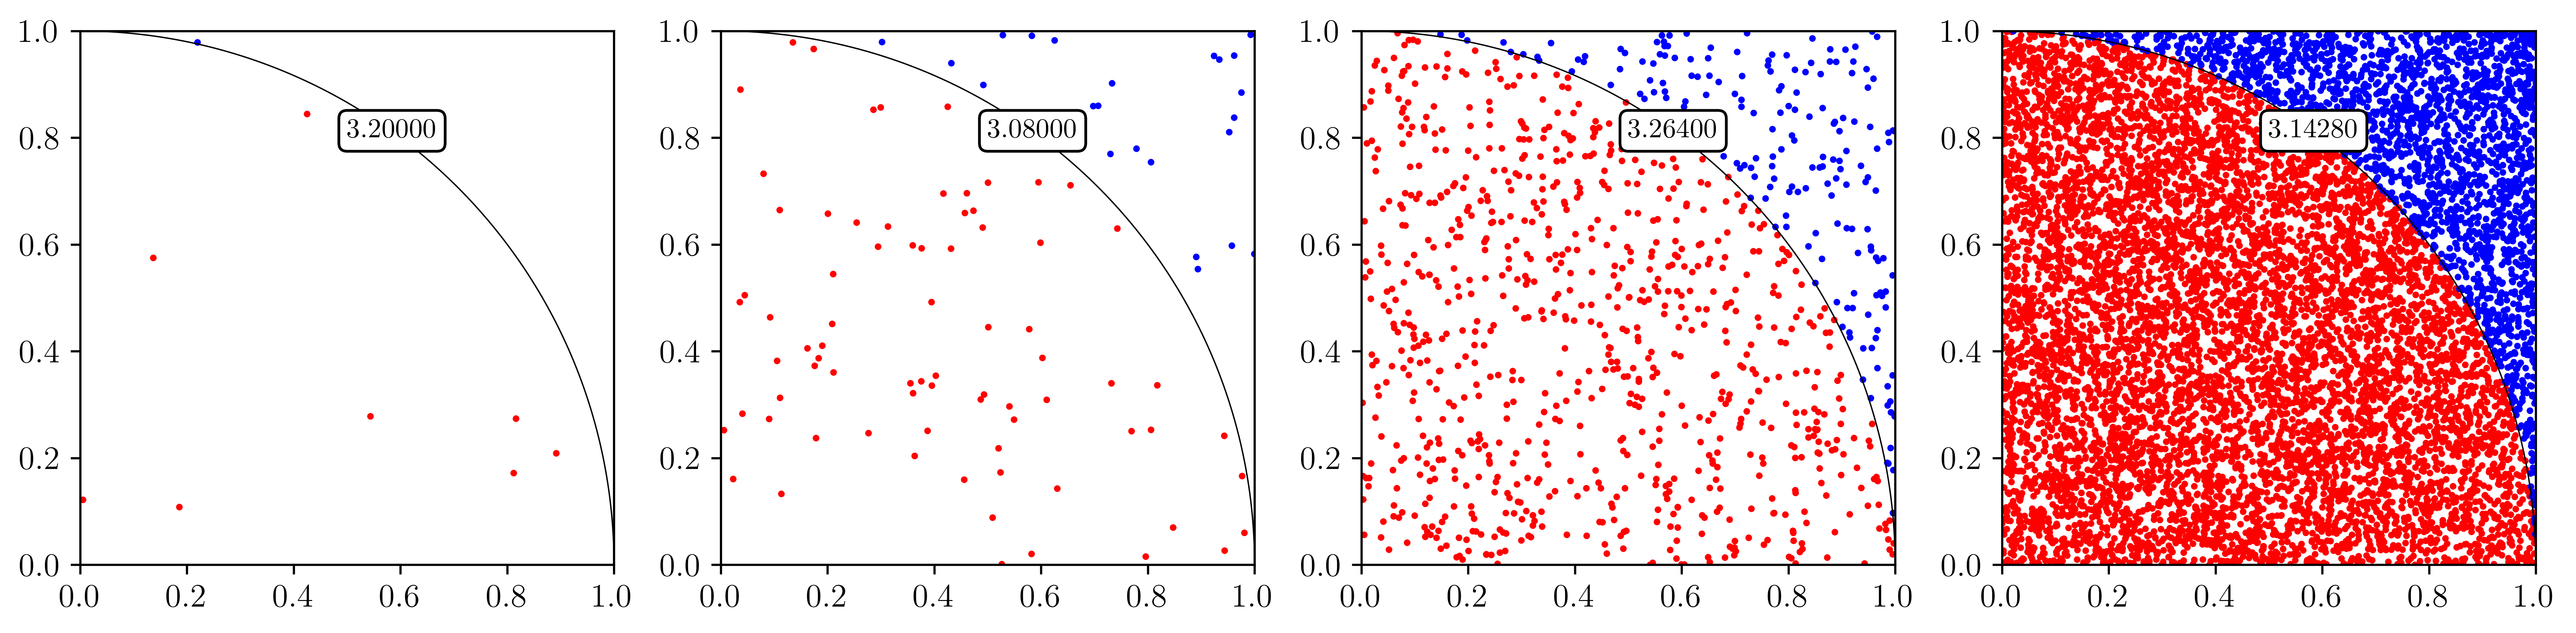

In [156]:
max_iters = 4
iters = np.logspace(1, max_iters, num=max_iters)

fig, ax = plt.subplots(1, max_iters, figsize=(16, 4), dpi=600)

theta = np.linspace(0, np.pi/2, 1000)

results = []

for j in range(max_iters):

    # Reset counters if you want each subplot independent
    i = 0
    o = 0

    # Unit circle
    ax[j].set_aspect('equal')
    ax[j].plot(np.cos(theta), np.sin(theta), linewidth=0.5, color='k')
    ax[j].set_xlim(0, 1)
    ax[j].set_ylim(0, 1)

    # Generate random points
    pts = np.random.rand(int(iters[j]), 2)

    # Vectorised radius test
    r = np.sum(pts**2, axis=1)
    inside_mask = r <= 1
    outside_mask = ~inside_mask

    # Count points
    i = np.sum(inside_mask)
    o = np.sum(outside_mask)

    # Plot in two batches (much faster than point-by-point)
    ax[j].scatter(pts[inside_mask, 0], pts[inside_mask, 1], c='r', s=2)
    ax[j].scatter(pts[outside_mask, 0], pts[outside_mask, 1], c='b', s=2)

    # Estimate pi
    result = 4 * i / (i + o)
    results.append([j, result])

    ax[j].text(
        0.5, 0.8, f"{result:.5f}",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black")
    )

(1.0, 5.0)

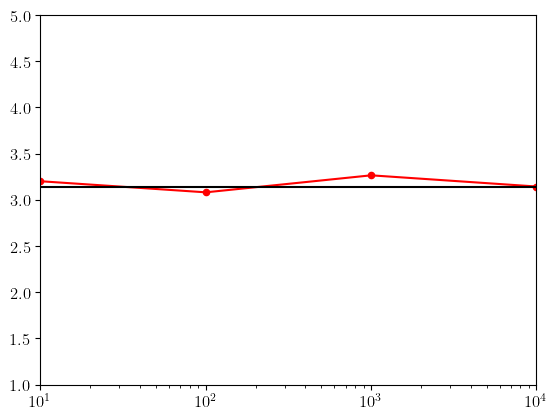

In [157]:
xs = [10**(j[0]+1) for j in results]
ys = [j[1] for j in results]

plt.scatter(xs, ys, s=20, c='r')
plt.plot(xs, ys, c='r')

# Real value of pi
x = np.linspace(10,10**(max_iters),1000)
y = np.linspace(np.pi, np.pi, 1000)
plt.plot(x,y, c='k')

plt.xscale("log")
plt.xlim(10,10**(max_iters))
plt.ylim(1,5)

Note, that we get a better estimate of $\pi$ when sampling 10 points rather than 1000 points. Here, we note that the Monte Carlo error goes as $\sim \frac{1}{\sqrt{N}}$, where $N$ is the number of samples (details can be found in [Appendx A2](#A2.-Variance-of-Monte-Carlo-Estimate)). Therefore, as the number of examples increases, the error in our estimate should decrease. Let's check this by performing many different Monte Carlo simulations.

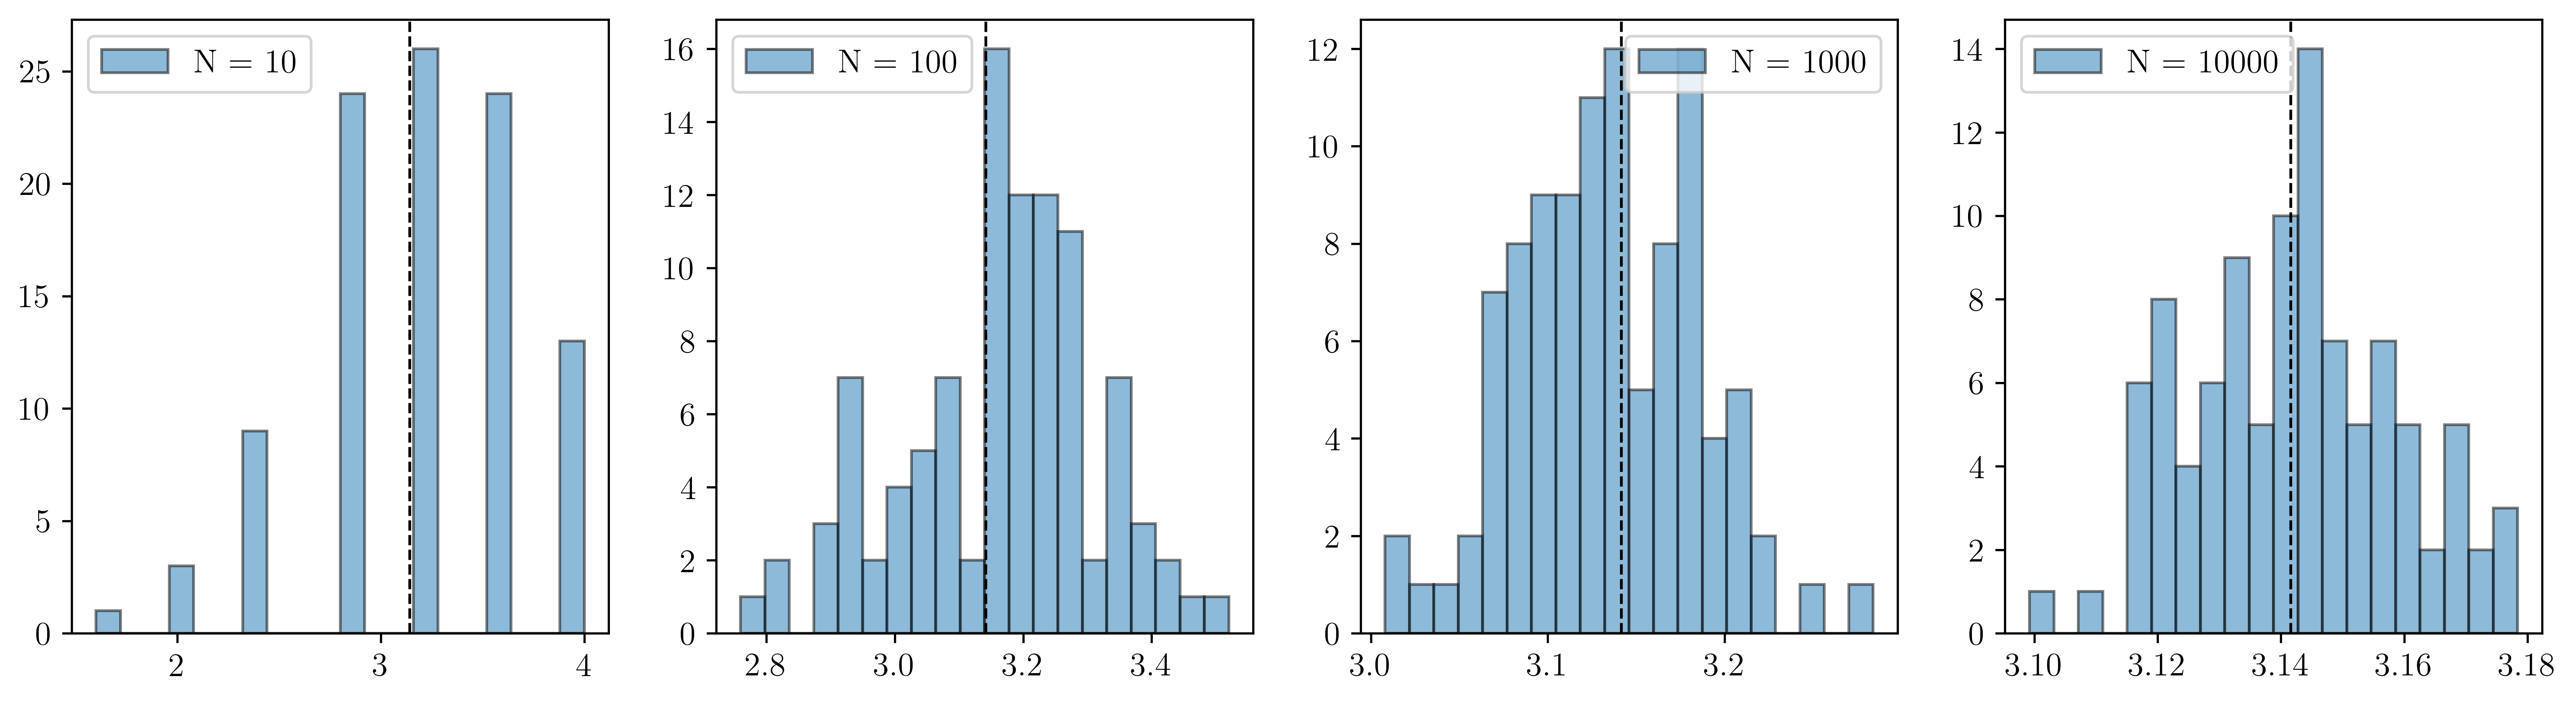

In [158]:
num_sims = 100

result_sims = []

for k in range(num_sims):

    max_iters = 4
    iters = np.logspace(1, max_iters, num=max_iters)
    results = []

    for j in range(max_iters):

        # Reset counters if you want each subplot independent
        i = 0
        o = 0

        # Generate random points
        pts = np.random.rand(int(iters[j]), 2)

        # Vectorised radius test
        r = np.sum(pts**2, axis=1)
        inside_mask = r <= 1
        outside_mask = ~inside_mask

        # Count points
        i = np.sum(inside_mask)
        o = np.sum(outside_mask)

        # Estimate pi
        result = 4 * i / (i + o)
        results.append([j, result])

    result_sims.append(results)

run10pts = []
run100pts = []
run1000pts = []
run10000pts = []
for i in range(num_sims):
    run10pts.append(result_sims[i][0][1])
    run100pts.append(result_sims[i][1][1])
    run1000pts.append(result_sims[i][2][1])
    run10000pts.append(result_sims[i][3][1])

fig, ax = plt.subplots(1, max_iters, figsize=(16, 4), dpi=600)
ax[0].hist(run10pts, bins=20, alpha=0.5, label=r'N = 10')
ax[1].hist(run100pts, bins=20, alpha=0.5, label=r'N = 100')
ax[2].hist(run1000pts, bins=20, alpha=0.5, label=r'N = 1000')
ax[3].hist(run10000pts, bins=20, alpha=0.5, label=r'N = 10000')
for i in range(4):
    ax[i].axvline(np.pi, color='k', linestyle='dashed', linewidth=1)
    ax[i].legend()

In [159]:
np.random.seed(12) 

## 2. Monte Carlo Estimate of Integrals

Monte Carlo approximation of integrals are useful when the dimensionality of the integral is large. 

Basic function on finite domain first -> demonstrate monte carlo vs standard numerical integration.
Then Gaussian -> Use importance sampling and/or domain splitting
Then multivariate Gaussian

We will start by performing Monte Carlo integration on a basic 1D function, i.e.

\begin{align}
I = \int_{a}^b dx \; f(x).
\end{align}

This can be approximated numerically as a Riemann sum

\begin{align}
I \approx \sum_{i=1}^{N} f(x_i)\Delta x_i = \frac{b-a}{N} \sum_{i=1}^{N} f(x_i).
\end{align}

However, this suffers from the curse of dimensionality, i.e. if $f(x)$ is N-dimensional and we need just 10 points in each dimension, then numerical integration requires 10^N computations. Instead, we can use stochastic sampling to approximate the integral. In this case, we have the same sum as above, but each point $x_i$ is drawn from a uniform distribution $\mathcal{U}(a,b)$.

As an example, let's consider

\begin{align}
I = \int_{-2}^2 dx \; x^2
\end{align}

whose actual value is $16/3 \approx 5.333...$. We'll calculate this integral using both direct numerical integration and Monte Carlo.

(1.0, 10.0)

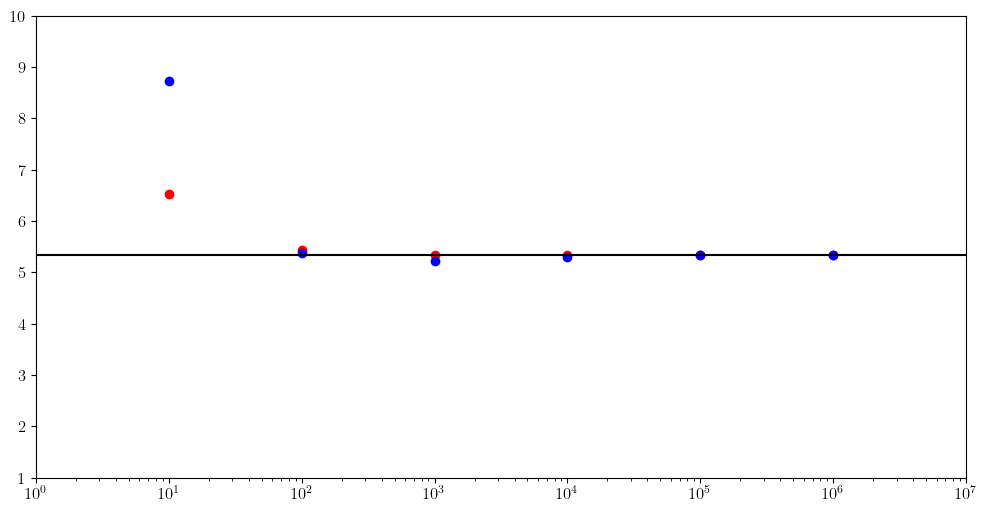

In [160]:
a = -2
b = 2

def f(x):
    return x**2

max_exp = 6
N_list = np.logspace(1,max_exp,max_exp)

fig, ax = plt.subplots(1,1, figsize=(12,6))

# Numerical Integration - Deterministic
def num_int(f, N, a, b):

    sum = 0
    xs = np.linspace(-2,2,N)
    for x_i in xs:
        sum += f(x_i)
    return ((b-a)/N) * sum

# Monte Carlo - Stochastic
def mc_int(f,N,a,b):

    sum = 0
    for i in range(N):
        # Normalization: x -> (b-a)x + a
        x_i = (b-a)*np.random.random_sample() + a
        sum += f(x_i)
    return ((b-a)/N) * sum

for N in N_list:

    N = int(N)
    ax.scatter(N,num_int(f,N,a,b), c='r')
    ax.scatter(N,mc_int(f,N,a,b), c='b')

x = np.linspace(0,10**(max_exp+1),1000)
y = np.linspace(16/3, 16/3, 1000)
plt.plot(x,y, c='k')
plt.xscale("log")
plt.xlim(1,10**(max_exp+1))
plt.ylim(1,10)

In [161]:
num_int_time = timeit.timeit(lambda: num_int(f,10,a,b), number=1)
print("Numerical Integration: ",num_int_time)

mc_int_time = timeit.timeit(lambda: mc_int(f,10,a,b), number=1)
print("Monte Carlo: ", mc_int_time)

Numerical Integration:  4.3125124648213387e-05
Monte Carlo:  9.417068213224411e-06


Now let's consider a 2D version of our integral. In general, a 2D integral has the form:

\begin{align}
    I = \int_{a}^b \int_{c}^d dx dy \; f(x,y)
\end{align}

which can be approximated by

\begin{align}
    I \approx \sum_{i=1}^{N_x} \sum_{j=1}^{N_y} f(x_i, y_j) \Delta A_{ij} = \frac{(b-a)(d-c)}{N_x N_y} \sum_{i=1}^{N_x} \sum_{j=1}^{N_y} f(x_i, y_j)
\end{align}

where $\Delta A_{ij} = \Delta x \Delta y$. Using $f(x,y) = x^2 y^2$, we have

\begin{align}
    I = \int_{-2}^2 \int_{-2}^2 dx dy \; x^2 \; y^2.
\end{align}

Using numerical integration techinques, this can be approximated as

\begin{align}
    I \approx = \frac{16}{N_x N_y} \sum_{i=1}^{N_x} \sum_{j=1}^{N_y} x_i^2 y_j^2
\end{align}

while using Monte Carlo techinques we have

\begin{align}
    I \approx = \frac{16}{N} \sum_{i=1}^{N}  x_i^2 y_i^2
\end{align}

(1, 100000)

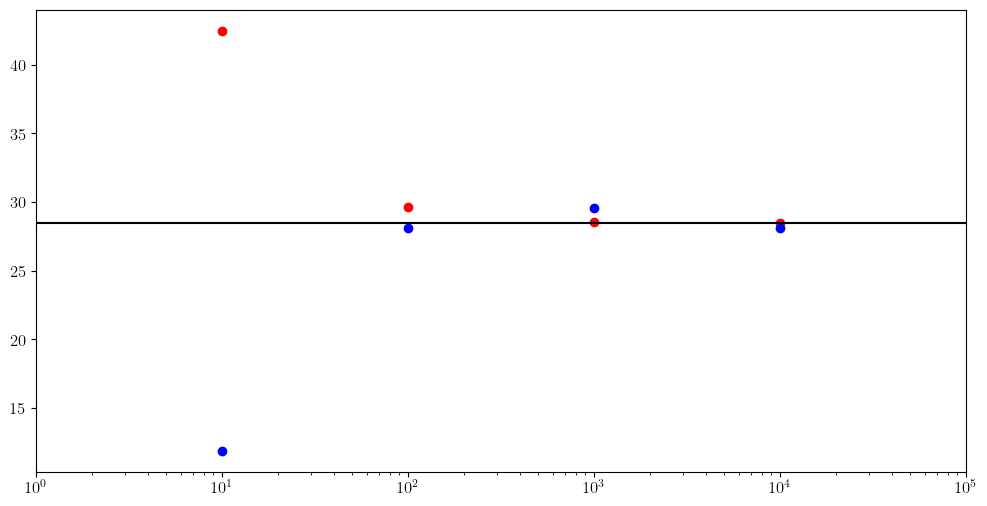

In [162]:
a = -2
b = 2
c = -2
d = 2

def f(x,y):
    return x**2 * y**2

max_exp = 4
N_list = np.logspace(1,max_exp,max_exp)

fig, ax = plt.subplots(1,1, figsize=(12,6))

# Numerical Integration - Deterministic
def num_int(f, N, a, b, c, d):

    sum = 0
    xs = np.linspace(-2,2,N)
    ys = np.linspace(-2,2,N)
    for x_i in xs:
        for y_j in ys:
            sum += f(x_i, y_j)
    return ((b-a)/N)*((d-c)/N) * sum

# Monte Carlo - Stochastic
def mc_int(f, N, a, b, c, d):

    sum = 0
    for i in range(N):
        # Normalization: x -> (b-a)x + a
        x_i = (b-a)*np.random.random_sample() + a
        y_j = (b-a)*np.random.random_sample() + a
        sum += f(x_i, y_j)
    return ((b-a)/N)*((d-c)) * sum

for N in N_list:

    N = int(N)
    ax.scatter(N,num_int(f,N,a,b,c,d), c='r')
    ax.scatter(N,mc_int(f,N,a,b,c,d), c='b')

x = np.linspace(0,10**(max_exp+1),1000)
y = np.linspace(256/9, 256/9, 1000)
plt.plot(x,y, c='k')
plt.xscale("log")
plt.xlim(1,10**(max_exp+1))

Note that our largest $N$ result is worse than the previous one. But this is ok, since this behaviour is typical of a stochastic process.

In [163]:
num_int_time = timeit.timeit(lambda: num_int(f,10000,a,b,c,d), number=1)
print("Numerical Integration: ",num_int_time)

mc_int_time = timeit.timeit(lambda: mc_int(f,10000,a,b,c,d), number=1)
print("Monte Carlo: ", mc_int_time)

Numerical Integration:  18.061410708120093
Monte Carlo:  0.005330875050276518


To fully demonstrate the power of Monte Carlo integration, we'll now look at a 10-D version of our integral:

\begin{align}
    I = \prod_{i = 1}^{15} \left(  \int_{-2}^{2} dx_i x_i^2 \right)
\end{align}

Numerical techniques are useless for this task, since if we want a resolution of only 10 points in each dimension, then we require $10^{10}$ evalations. We can already see from above, that for 10000 points, 2D problems require $\mathcal{O}(10)s$... However, using Monte Carlo techniques we can use

\begin{align}
    I \approx \frac{4^{10}}{N} \sum_{j=1}^N x_{1,j}^2 x_{2,j}^2 \cdots x_{10,j}^2
\end{align}

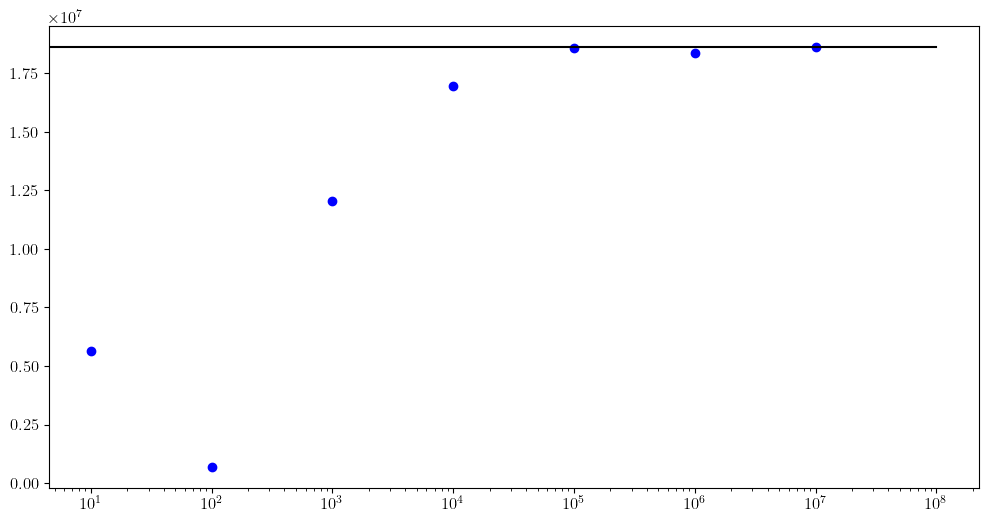

In [164]:
def f(x1,x2,x3,x4,x5,x6,x7,x8,x9,x10):
    return x1**2 * x2**2 * x3**2 * x4**2 * x5**2 * x6**2 * x7**2 * x8**2 * x9**2 * x10**2

max_exp = 7
N_list = np.logspace(1,max_exp,max_exp)

fig, ax = plt.subplots(1,1, figsize=(12,6))

# Monte Carlo - Stochastic
def mc_int(f, N, a, b):

    sum = 0
    for i in range(N):
        # Normalization: x -> (b-a)x + a
        x1 = (b-a)*np.random.random_sample() + a
        x2 = (b-a)*np.random.random_sample() + a
        x3 = (b-a)*np.random.random_sample() + a
        x4 = (b-a)*np.random.random_sample() + a
        x5 = (b-a)*np.random.random_sample() + a
        x6 = (b-a)*np.random.random_sample() + a
        x7 = (b-a)*np.random.random_sample() + a
        x8 = (b-a)*np.random.random_sample() + a
        x9 = (b-a)*np.random.random_sample() + a
        x10 = (b-a)*np.random.random_sample() + a
        sum += f(x1,x2,x3,x4,x5,x6,x7,x8,x9,x10)
    return (((b-a)**10)/N) * sum

for N in N_list:

    N = int(N)
    ax.scatter(N,mc_int(f,N,a,b), c='b')

x = np.linspace(0,10**(max_exp+1),1000)
y = np.linspace((16/3)**10, (16/3)**10, 1000)
plt.plot(x,y, c='k')
plt.xscale("log")

### 2.1 Monte Carlo Estimation of Expectation Values

Let's now say that we wish to evaluate the expectation values of some random variable, X, that follows a probability distribution $p_X(x)$:

\begin{align}
    E(X) = \int dx \; x \; p_X(x)
\end{align}

We can evaluate this using Monte Carlo integration. Following a similar logic to above, we can write (making the normalisation explicit)

\begin{align}
    E_p[X] = \frac{\int dx x p(x)}{\int dx p(x)} \approx  \frac{\sum_{i=1}^N x_i p(x_i) \Delta x_i}{\sum_{i=1}^N p(x_i) \Delta x_i}
\end{align}

Note that if our samples are drawn from $p(x)$, then the parameter space volume associated to each sample is inversely proportional to the PDF, i.e. $p(x_i) \propto 1/\Delta x_i$ or $p(x_i) = c/\Delta x_i$. This allows us to write

\begin{align}
    E_p[X] \approx \frac{\sum_{i=1}^N c x_i }{\sum_{i=1}^N c} = \frac{c}{cN} \sum_{i=1}^N x_i = \frac{1}{N} \sum_{i=1}^N x_i
\end{align}

The law of large numbers states that the mean of a set of independent and identically distributed samples tends to the theoretical expectation value in the large sample limit, i.e

\begin{align}
    \lim_{N \to \infty} \frac{1}{N} \sum_{i=1}^{N} x_i = E(X)
\end{align}

Therefore, we can estimate our integral using

\begin{align}
    \int dx \; x \; p_X(x) \approx \frac{1}{N} \sum_{i=1}^N x_i
\end{align}

For simplicity, let's assume that our probaility distribution is a Gaussian, i.e. $p_X(x) \sim \mathcal{N}(\mu, \sigma)$.

In [165]:
mu = 10
sigma = 3

N = 10000

sum = 0
for i in range(N):
    x = np.random.normal(mu,sigma)
    sum += x

Ex = sum/N

print(Ex)

10.02437911271087


We can further generalise this to arbitrary functions:

\begin{align}
   \int dx\; f(x) \;p_X(x) \approx \frac{1}{N} \sum_{i=1}^N f(x_i)
\end{align}

Note that this is equivalent to the discussion above from the start of [Section 2](##2.-Monte-Carlo-Estimate-of-Integrals), since

\begin{align}
\int dx\; f(x) = \int dx\; \frac{f(x)}{p(x)} p(x) \approx \frac{1}{N} \sum_{i=1}^N \frac{f(x_i)}{p(x_i)}
\end{align}

and noting that $p(x_i) = \frac{1}{b-a}$ for $p(X) \sim \mathcal{U}(a,b)$, where $x_i$ is understood to be sampled from $p(x)$.

Let's take $f(x) = \frac{1}{x}$

In [166]:
mu = 10
sigma = 3

N = 10000

sum = 0
for i in range(N):
    x = np.random.normal(mu,sigma)
    sum += 1/x

print(sum/N)

# Rough numerical integration as a sanity check

b = 20
a = 1

def normal(x, mu, sigma):
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

sum = 0
xs = np.linspace(a,b,N)
for x_i in xs:
    sum += (1/x_i) * normal(x_i, mu, sigma)
print((b-a)*sum/N)

0.1133029277662303
0.11246781437080854


### 2.2 Monte Carlo Estimation of Variance

Now let's say that we wish to estimate the variance of a function $f(X)$ using Monte Carlo techniques. If we know the mean, $\mu = E_p[f(X)]$, exactly then we can compute

\begin{align}
    Var[f(X)] = E_p[(f(X)-\mu)^2] = \int dx (f(x) - \mu)^2 p(x) \approx \frac{1}{N} \sum_{i=1}^N (f(x_i)-\mu)^2.
\end{align}

exactly as we have just done. This gives an unbiased estimator, since

\begin{align}
E_p[\frac{1}{N} \sum_{i=1}^N (f(x_i)-\mu)^2] = \frac{1}{N} \sum_{i=1}^N E_p[(f(x_i)-\mu)^2] = \frac{1}{N} \sum_{i=1}^N E_p[f(x_i)^2 - 2\mu f(x_i) + \mu^2] = \frac{1}{N} \sum_{i=1}^N \left( E_p[f(x_i)^2] - 2\mu E_p[f(x_i)] + \mu^2 \right) = \frac{1}{N} \sum_{i=1}^N \left( E_p[f(x_i)^2] - \mu^2 \right) = \frac{N}{N} (E_p[f(X)^2] - \mu^2) = Var[f(X)]
\end{align}

However, if we are computing a Monte Carlo estimate of the variance, it is likely that we only have a Monte Carlo estimate of $\mu$, which we'll denote $\hat{\mu} = \frac{1}{N} \sum_{i=1}^N f(x_i)$. Naively, we may take our Monte Carlo estimate of the variance to be $\sum_{i=1}^N (f(x_i)-\hat{\mu})^2$. We wish for this to be an unbiased estimate, so this serves as our starting point

\begin{align}
    E_p[\frac{1}{N} \sum_{i=1}^N (f(x_i) - \hat{\mu})^2] = \frac{1}{N} E_p[\sum_{i=1}^N (f(x_i) - \mu - (\hat{\mu} - \mu))^2] = \frac{1}{N} E_p[ \sum_{i=1}^N (f(x_i) - \mu)^2 - 2(\hat{\mu}-\mu)\sum_{i=1}^N (f(x_i) - \mu) + N(\hat{\mu} - \mu)]
\end{align}

Since $\sum_{i=1}^N (f(x_i) - \mu) = N(\hat{\mu} - \mu)$, we have

\begin{align}
    E_p[\frac{1}{N} \sum_{i=1}^N (f(x_i) - \hat{\mu})^2] = \frac{1}{N} E_p[\sum_{i=1}^N (f(x_i) - \mu)^2 - N(\hat{\mu} - \mu)^2] = \frac{1}{N} E_p[\sum_{i=1}^N (f(x_i) - \mu)^2] - N E_p[(\hat{\mu} - \mu)^2]
\end{align}

Using results from above and [Appendx A2](#A2.-Variance-of-Monte-Carlo-Estimate), we find

\begin{align}
    E_p[\frac{1}{N} \sum_{i=1}^N (f(x_i) - \hat{\mu})^2] = Var[f(X)] - E_p[(\hat{\mu} - \mu)^2] = Var[f(X)] - \frac{Var[f(X)]}{N}
\end{align}

Rearranging, we reach the desired result

\begin{align}
    E_p[\frac{1}{N-1} \sum_{i=1}^N (f(x_i) - \hat{\mu})^2] = Var[f(X)]
\end{align}

which informs us that

\begin{align}
    Var[f(X)] \approx \frac{1}{N-1} \sum_{i=1}^N (f(x_i) - \hat{\mu})^2
\end{align}

is the natural unbiased estimator of the variance.

Let's look at an example involving a Gaussian, $p(X) \sim \mathcal{N}(\mu, \sigma)$, since we know how the variance should behave. Expliclty, we are interested in approximating

\begin{align}
    Var(X) = \int dx (x-\mu)^2 p(x)
\end{align}

for both known $\mu$ and its Monte Carlo estimate, $\mu$. We'll compute the Monte Carlo estimate as above, but using less samples to emphasise the point.

In [167]:
mu = 10
sigma = 3

N = 10

sum = 0
for i in range(N):
    x = np.random.normal(mu,sigma)
    sum += x

Ex = sum/N
print(Ex)

10.186702677478305


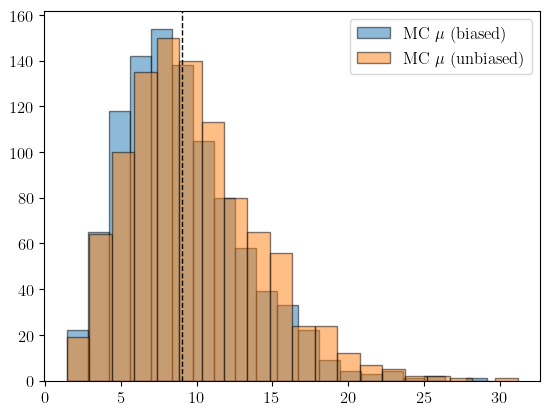

In [168]:
ntrials = 1000

vars2 = []
vars3 = []

for i in range(ntrials):

    # With MC mean

    sum = 0
    for i in range(N):
        x = (np.random.normal(mu,sigma) - Ex)**2
        sum += x

    var2 = sum/(N-1)

    # Incorrectly using MC mean but dividing by N

    sum = 0
    for i in range(N):
        x = (np.random.normal(mu,sigma) - Ex)**2
        sum += x

    var3 = sum/(N)

    vars2.append(var2)
    vars3.append(var3)

plt.hist(vars3, bins=20, alpha=0.5, label=r'MC $\mu$ (biased)')
plt.hist(vars2, bins=20, alpha=0.5, label=r'MC $\mu$ (unbiased)')

plt.axvline(sigma**2, color='k', linestyle='dashed', linewidth=1)
plt.legend()

## 3. Importance Sampling

Let's say that we wish to evaluate the expected value of some function of a random variable $X$ under some probability distribution $p(x)$. We can calculate this as 

\begin{align}
E_p[f(X)] = \int dx f(x) p(x).
\end{align}

Let's now consider performing a Monte Carlo estimate of this integral

\begin{align}
E_p[f(X)] \approx \frac{1}{N} \sum_{i=1}^N f(x_i).
\end{align}

with samples taken from $p(x)$. As an example, let's take $f(x) = 20e^{-100x**2}$ and $p(x) \approx \mathcal{U}(-10,10)$. There is no closed form solution to this integral, so we'll evaluate it numerically.

In [169]:
b = 50
a = -50

def f(x):
    return 20*np.exp(-100*x**2)

def p(x):
    return np.where((x >= a) & (x <= b), 1/(b - a), 0)

#def convolution(x):

def num_int(x):    
    sum = 0
    for val in x:
        sum += f(val)*p(val)
    return (b-a)*sum/len(x)

(-5.0, 5.0)

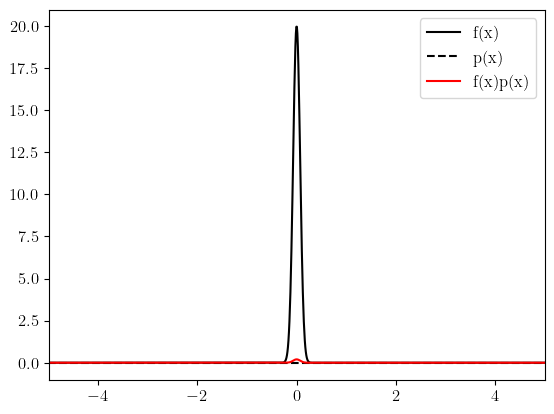

In [170]:
x = np.linspace(-50,50,10000)

plt.plot(x,f(x), c='k', label='f(x)')
plt.plot(x,p(x), c='k', linestyle='dashed', label='p(x)')
plt.plot(x, f(x)*p(x), c='r', label=r'f(x)p(x)')

plt.legend()

plt.xlim(-5,5)

In [171]:
result = num_int(x)

Here, we see that the main contribution to the integral comes from the domain $\sim [-0.3, 0.3]$. With this in mind, let's attempt a Monte Carlo simulation, with samples from $p(x)$.

In [172]:
def mc_integral(f, p, N, a, b):

    xs = []

    sum = 0
    for i in range(N):
        x_i = (b-a)*np.random.random_sample() + a
        sum += f(x_i)
        xs.append(x_i)
    return [(1/N) * sum, xs]

In [173]:
mc_result = mc_integral(f, p, 50, a, b)
print(mc_result[0])

1.681747454899613e-70


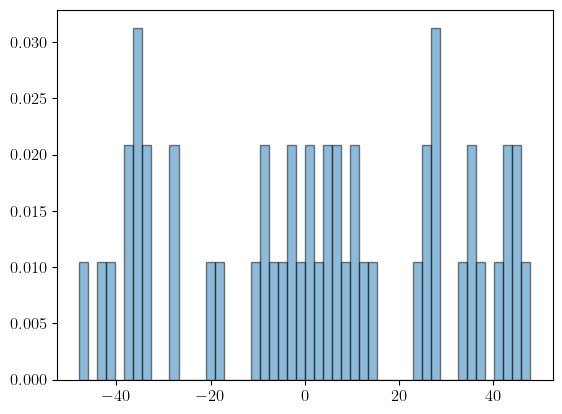

In [174]:
plt.hist(mc_result[1], bins=50, density=True, alpha=0.5, label='Sampled x values')
plt.show()

We see that most of our samples are outside of the domain that primarily contributes to the integral, so the final result is way off. In principle, we can increase the number of samples...

0.030284420470696616


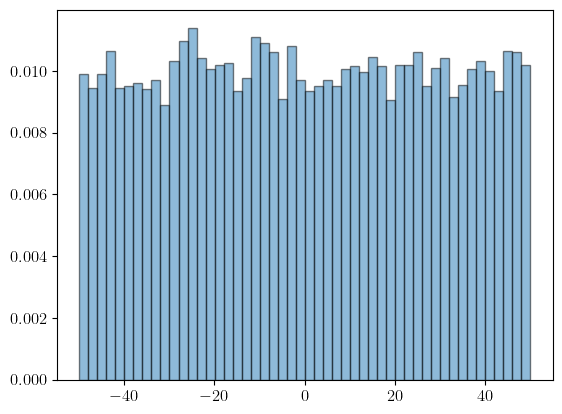

In [175]:
mc_result = mc_integral(f, p, 10000, a, b)
print(mc_result[0])
plt.hist(mc_result[1], bins=50, density=True, alpha=0.5, label='Sampled x values')
plt.show()

...and we get a much better result. This isn't desireable though as it is much more expensive for harder problems. Instead, let's revisit our integral and make a slight change by introducing a new probability distribution $q(x)$, known as the proposal distribution:

\begin{align}
E_p[f(X)] = \int dx f(x) p(x) = \int dx \frac{f(x) p(x)}{q(x)} q(x) = E_q\Bigg[\frac{f(X)}{p(X)}{q(X)}\Bigg]
\end{align}

where $E_q$ is understood to be calculated using samples from $q(x)$. This is the fundamental point of importance sampling, we can obtain the expectation value of a function with respect to $p(x)$ using samples from a different distribution $q(x)$. In other words, each sample is rewighted by a factor of $w_i = p(x)/q(x)$ to account for the fact that we are taking samples from a different distribution:

\begin{align}
E_q\Bigg[\frac{f(X)}{p(X)}{q(X)}\Bigg] \approx \frac{1}{N} \sum_{i=1} \frac{f(x_i)p(x_i)}{q(x_i)} = \frac{1}{N} \sum_{i=1} f(x_i) w_i 
\end{align}

Before we proceed with how this works in practise, there are a few points to note. First, is that the Monte Carlo estimate of $E_q[\cdots]$, is an unbiased estimator of E_p[f(X)]. This calculate closely follows that of [Appendx A1](#A1.-Expectation-Value-of-Monte-Carlo-Estimate). Futhermore, we wish to choose a proposal distribution such that the variance of $E_q[\cdots]$ is minimized. The variance calculation closely follows [Appendx A2](#A2.-Variance-of-Monte-Carlo-Estimate), and is found to be

\begin{align}
Var[\frac{1}{N}\sum_{i=1}^N \frac{f(x_i)}{p(x_i)}{q(x_i)}] = \frac{1}{N} \int dx \frac{(f(x)p(x) - E_p[f(X)]q(x))^2}{q(x)}
\end{align}

Hence, to minimise this error, we must choose our proposal distribution $q(x)$ s.t. $q(x) \sim \frac{f(x)p(x)}{E_p[f(X)]}$. In our example, we can simply look at our distribution and see that something like $q(x) \sim \mathcal{N(\mu, \sigma)}$ should work just fine.


In [176]:
def q(x,mu,sigma):
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

(-5.0, 5.0)

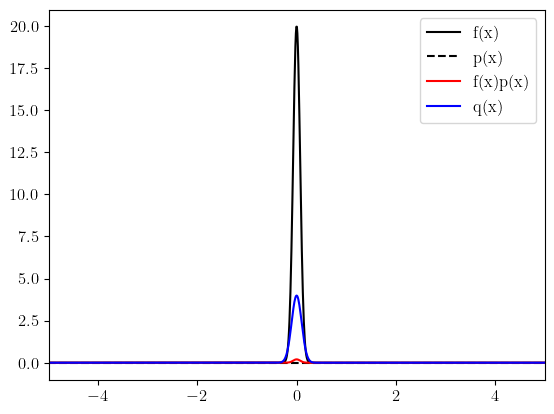

In [177]:
mu = 0
sigma = 0.1

x = np.linspace(-50,50,10000)

plt.plot(x,f(x), c='k', label='f(x)')
plt.plot(x,p(x), c='k', linestyle='dashed', label='p(x)')
plt.plot(x, f(x)*p(x), c='r', label=r'f(x)p(x)')
plt.plot(x, q(x,mu,sigma), c='b', label='q(x)')

plt.legend()

plt.xlim(-5,5)

In [178]:
def mc_integral_importance(f, p, N, a, b):

    xs = []

    sum = 0
    for i in range(N):
        x_i = np.random.normal(mu, sigma)
        sum += f(x_i)*p(x_i)/q(x_i, mu, sigma)
        xs.append(x_i)
    return [(1/N) * sum, xs]

In [179]:
mc_result = mc_integral_importance(f, p, 50, a, b)
print(mc_result[0])

0.03712310948716882


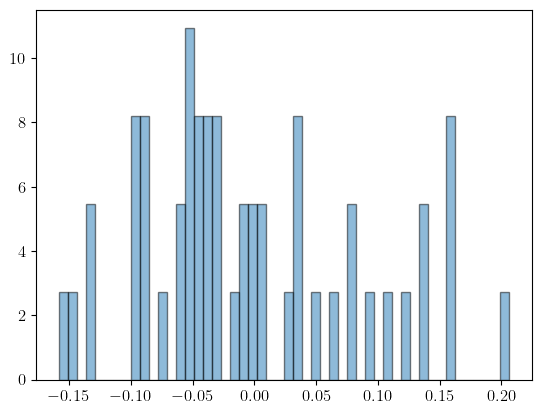

In [180]:
plt.hist(mc_result[1], bins=50, density=True, alpha=0.5, label='Sampled x values')
plt.show()

Clearly, we see that there are more samples near our region of interest by sampling w.r.t a Gaussian distribution, and we have got a respectable answer for the expectation value of $f(X)$ using much less samples than if we had sampled from the uniform distribution.

### 3.1 Self-Normalised Importance Sampling & Effective Sample Size

Let's now consider that we don't know the normalisation of some probability distribution, $p(x)$. Taking $p(x) = c_p p_0(x)$, this means that we only know the shape of the distribution, $p_0 (x)$. Likewise, this may also be the case for the proposal distribution $q(x) = c_q q_0 (x)$. In this case, our expectation value of some function $f(X)$ of a random variable $X$ under $p(x)$ is

\begin{align}
    E_p[f(X)] = E_q[\frac{f(X)p(X)}{q(X)}] = \frac{\int dx \frac{f(x)p(x)}{q(x)} q(x)}{\int dx \frac{p(x)}{q(x)} q(x)} = \frac{\int dx \frac{f(x)c_p p_0(x)}{c_q q_0(x)} q(x)}{\int dx \frac{c_p p_0(x)}{c_q q_0(x)} q(x)} = \frac{\int dx \frac{f(x) p_0(x)}{q_0(x)} q(x)}{\int dx \frac{p_0(x)}{q_0(x)} q(x)} = \frac{\int dx f(x) w_0(x) q(x)}{\int dx w_0(x) q(x)} \approx \frac{\sum_{i=1}^N f(x_i)w_0(x_i)}{\sum_{i=1}^N w_0(x_i)} = \hat{\mu}
\end{align}

We want a confidence interval for this estimate. From [Appendix A3](##A3.-Delta-Method-and-Variance-of-a-Ratio-of-Means), we have an approximate variance of $\hat{\mu}$

\begin{align}
    Var[\hat{\mu}] = \frac{1}{N} \frac{E_p[(f(X)w(X) - \mu w(X))^2]}{E_p[w(X)]^2} \approx \frac{1}{N} \frac{\frac{1}{N} \sum_{i=1}^N w_0(x_i)^2 (f(x_i) - \hat{\mu})^2}{(\frac{1}{N} \sum_{i=1}^N w_0(x_i))^2} = \sum_{i=1}^N w_i^2 (f(x_i)-\hat{\mu})^2 
\end{align}

where $w_i = \frac{w_0(x_i)}{\sum_{j=1}^N w_0(x_j)}$. 

In certain circumstances, it is possible that most of the weights are zero (or close to zero) and so only a few weights/samples actually contribute to the estimate. In that case, we are likely to get a large error on our estimate. To quantify this, consider

\begin{align}
    E_p[f(X)] \approx \frac{\sum_{i=1}^N f(x_i) w(x_i)}{\sum_{i=1}^N w(x_i)}
\end{align}

The unweighted mean of $E_p[f(X)] \approx \frac{1}{n} \sum_{i=1}^N f(x_i)$ has a variance  of $Var[E_p[f(X)]] = \frac{\sigma^2}{n_e}$. Setting this equal to the variance of the weighted mean, we get

\begin{align}
    Var[E_p^w[f(X)]] = \frac{\sigma^2}{n_e} = Var[E_p^u[f(X)]]  \\
    \frac{1}{n_e}\sum_{i=1}^N (f(x_i) - \mu)^2 = \frac{\sum_{i=1}^N w_0(x_i)^2 (f(x_i) - \mu)^2}{ (\sum_{i=1}^N w_0(x_i))^2} \\
    (\sum_{i=1}^N w_0(x_i))^2 \sum_{i=1}^N (f(x_i) - \mu)^2 = n_e \sum_{i=1}^N w_0(x_i)^2 (f(x_i) - \mu)^2 \\
    (\sum_{i=1}^N w_0(x_i))^2 \sum_{i=1}^N \left( (f(x_i) - \mu)^2 - n_e \frac{w_0(x_i)^2 (f(x_i) - \mu)^2}{(\sum_{i=1}^N w_0(x_i))^2} \right) \\
    n_e = \frac{(\sum_{i=1}^N w(x_i))^2}{\sum_{i=1}^N w(x_i)^2}
\end{align}

$n_e$ is called the effective sample size, and corresponds to the number of samples needed without using weights to obtain the same variance. Let's see how this works with an example.

We want to find the expectation value of $f(x) = x^2$ under the un-normalised ditstribution $p(x) = \frac{c}{10} e^{-x^4 + x^2}$. Since we don't know $c$, we can't generate samples from this distribution. Instead, we can propose a similar normalised distribution, such as $q(x) \sim \mathcal{N}(0,1)$. In practise, we could normalise $p(x)$ by computing $\int dx p(x)$ numerically. However, for demonstration purposes we'll just say we can't. In the case of higher dimensional integrals, we really can't normalise and self-normalised importance sampling is useful.

In [320]:
def p_0(x):

    return (1/10)*np.exp(-x**4 + x**2)

def f(x):

    return x**2

b = 10
a = -10
N = 10000
x = np.linspace(a,b,N)

exp_val_num = ((b-a)/N * np.sum(f(x_i)*p_0(x_i) for x_i in x)) / ((b-a)/N * np.sum(p_0(x_i) for x_i in x))
print("Numerical Integration: ", exp_val_num)


Numerical Integration:  0.5208986482435782


/var/folders/r3/ppt35m3n4zn12w8wdv97lylm0000gr/T/ipykernel_68171/2951800073.py:14: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  exp_val_num = ((b-a)/N * np.sum(f(x_i)*p_0(x_i) for x_i in x)) / ((b-a)/N * np.sum(p_0(x_i) for x_i in x))


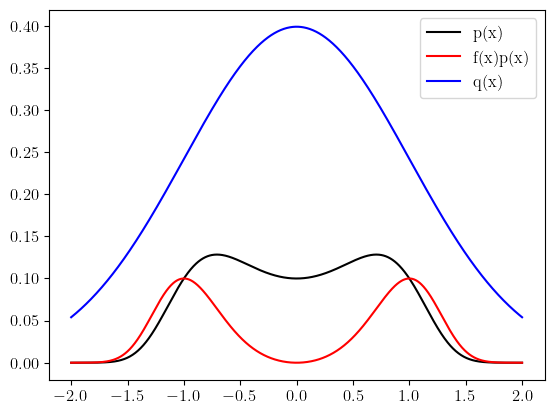

In [322]:
x = np.linspace(-2,2,1000)

mu = 0
sigma = 1

plt.plot(x, p_0(x), c='k', label='p(x)')
plt.plot(x, f(x)*p_0(x), c='r', label=r'f(x)p(x)')
plt.plot(x, q(x, mu, sigma), c='b', label='q(x)')

plt.legend()

Now, let's take samples from our proposal distribution and compute the weights. In our case, we cannot compute the weights directly as we do not know the normalisation of $p(x)$. However, we can self-normalise the weights via 

\begin{align}
w(x_i) = \frac{w_0(x_i)}{\sum_{j=1}^N w_0(x_i)}
\end{align}

where $w_0(x_i) = \frac{p_0(x_i)}{q(x_i)}$.

In [323]:
n_samples = 10000
mu = 0
sigma = 1

samples = np.zeros(n_samples)

for i in range(n_samples):
    x_i = np.random.normal(0, 1)
    samples[i] = x_i

# Compute un-normalized importance weights
w_0s = []
for x_i in samples:
    w_0s.append(p_0(x_i)/q(x_i, mu, sigma)) 

sum_ws = np.sum(w_0s)
# Normalize the weights
ws = np.array(w_0s) / sum_ws

exp_val = np.sum(ws * f(samples)) / np.sum(ws)

print("Importance Sampling: ", exp_val)

Importance Sampling:  0.522952578763958


Now let's vary the mean of the proposal distribution $q(x) \sim \mathcal{N}(\mu,1)$ and see how the effective sample size changes.

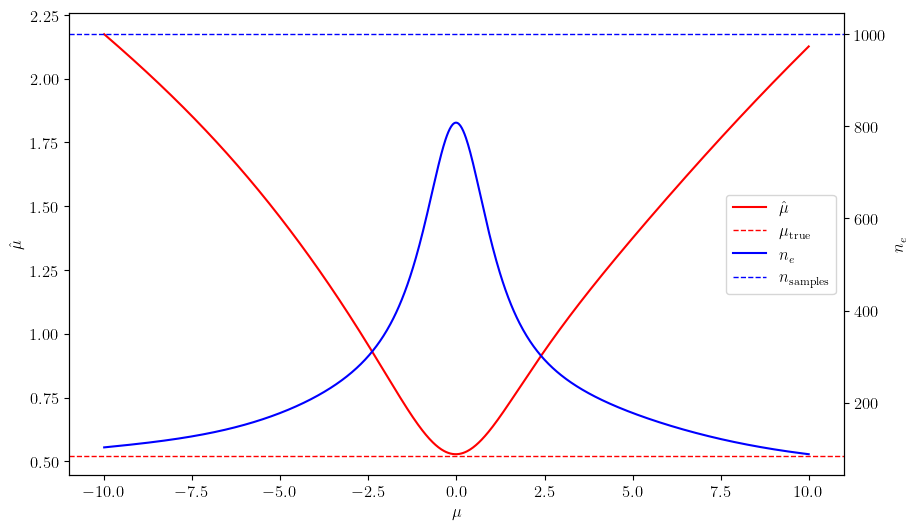

In [326]:
fig, ax_left = plt.subplots(figsize=(10, 6))
ax_right = ax_left.twinx()

n_samples = 1000

mus = np.linspace(-10,10,1000)

samples = np.zeros(n_samples)

for i in range(n_samples):
    x_i = np.random.normal(0, 1)
    samples[i] = x_i

exp_vals = []
nes = []
for mu in mus:

    # Compute un-normalized importance weights
    w_0s = []
    for x_i in samples:
        w_0s.append(p_0(x_i)/q(x_i, mu, sigma)) 

    sum_ws = np.sum(w_0s)
    # Normalize the weights
    ws = np.array(w_0s) / sum_ws

    exp_val = np.sum(ws * f(samples)) / np.sum(ws)

    exp_vals.append(exp_val)
    nes.append(np.sum(ws)**2 / np.sum(ws**2))

line1 = ax_left.plot(mus, exp_vals, c='r', label=r'$\hat{\mu}$')
line2 = ax_right.plot(mus, nes, c='b', label=r'$n_e$')

ax_left.set_xlabel(r'$\mu$')
ax_left.set_ylabel(r'$\hat{\mu}$')
ax_right.set_ylabel(r'$n_e$')

line1 += [ax_left.axhline(exp_val_num, color='r', linestyle='--', linewidth=1, label=r'$\mu_\mathrm{true}$')]
line2 += [ax_right.axhline(n_samples, color='b', linestyle='--', linewidth=1, label=r'$n_\mathrm{samples}$')]

plt.legend(line1 + line2, [l.get_label() for l in line1 + line2], loc='best')
plt.show()

Clearly, as the effective sample size increases, so does our estimate. Therefore, computing the effective sample size is a good proxy for how good our proposal distribution is.

### 3.2 Rejection Sampling

To-Do

# Appendix

## A1. Expectation Value of Monte Carlo Estimate

Here, we demonstrate how to compute the expectation value of the Monte Carlo estimate of an arbitrary function. For a funtion $f(X)$ of a random variable $X$, the expectation value under a probability distribution $p(x)$ is computed as

\begin{align}
    E_p[f(X)] = \int dx f(x) p(x)
\end{align}

To compute the expectation value of a Monte Carlo esimate, we simply substitute $f(X) \rightarrow \frac{1}{N} \sum_{i=1}^N f(x_i)$, which gives us

\begin{align}
    E_p[\frac{1}{N} \sum_{i=1}^N f(x_i)] = \frac{1}{N} \sum_{i=1}^N E_p[f(x_i)] = \frac{1}{N} \sum_{i=1}^N \int dx_i f(x_i) p(x_i) = \frac{1}{N} \sum_{i=1}^N E_p[f(X)] = \frac{N}{N} E_p[f(X)] = E_p[f(X)]
\end{align}

This result demonstrates that the Monte Carlo estimate is an unbiased estimator, since the expected result coincides with that of the true result.

## A2. Variance of Monte Carlo Estimate

For a function $f(X)$ of a random variable $X$, the variance under a probability distribution $p(x)$ is 

\begin{align}
Var[f(X)] = E_p[(f(X) - E_p[f(X)])^2]
\end{align}

As above, to get the variance of the Monte Carlo estimate, we make the substitution $f(X) \rightarrow \frac{1}{N} \sum_{i=1}^N f(x_i)$

\begin{align}
Var[\frac{1}{N} \sum_{i=1}^N f(x_i)] = E_p[(\frac{1}{N} \sum_{i=1}^N f(x_i))^2] - E_p[\frac{1}{N} \sum_{i=1}^N f(x_i)]^2 = E_p[(\frac{1}{N} \sum_{i=1}^N f(x_i))^2] - E_p[f(X)]^2
\end{align}

where we use the result from above. Let's now focus on the first term in this expression:

\begin{align}
E_p[(\frac{1}{N} \sum_{i=1}^N f(x_i))^2] = \frac{1}{N^2} E_p[(\sum_{i=1}^N f(x_i))^2] = \frac{1}{N^2} E_p[\sum_{i=1}^N \sum_{j=1}^N f(x_i) f(x_j)]
\end{align}

Splitting this sum into diagonal and off-diagonal, we get

\begin{align}
E_p[(\frac{1}{N} \sum_{i=1}^N f(x_i))^2] = \frac{1}{N^2} E_p[\sum_{i=j} \sum_{j=1}^N f(x_i) f(x_j) + \sum_{i \ne j} \sum_{j=1}^N f(x_i) f(x_j)] = \frac{1}{N^2} E_p[\sum_{j=1}^N f(x_j)^2 + \sum_{i \ne j} \sum_{j=1}^N f(x_i) f(x_j)]
\end{align}

Now taking the summation symbols outside, we find (assuming that each sample is independent)

\begin{align}
E_p[(\frac{1}{N} \sum_{i=1}^N f(x_i))^2] = \frac{1}{N^2} \left( \sum_{j=1}^N E_p[f(x_j)^2] + \sum_{i \ne j} \sum_{j=1}^N E_p [f(x_i) f(x_j)] \right) = \frac{1}{N^2} \left( \sum_{j=1}^N E_p[f(x_j)^2] + \sum_{i \ne j} \sum_{j=1}^N E_p [f(x_i)] [f(x_j)] \right)
\end{align}

In the last term, the second sum gives a factor of $N$, while the first one gives $N-1$, hence

\begin{align}
E_p[(\frac{1}{N} \sum_{i=1}^N f(x_i))^2] = \frac{1}{N^2} \left( N E_p[f(X)^2] +  N(N-1) E_p [f(X)]^2 \right)
\end{align}

Putting everything together, we get

\begin{align}
Var[\frac{1}{N} \sum_{i=1}^N f(x_i)] = \frac{1}{N^2} \left( N E_p[f(X)^2] +  N(N-1) E_p [f(X)]^2 \right) - E_p[f(X)]^2 = \frac{1}{N^2} \left( N E_p[f(X)^2] +  N^2 E_p [f(X)]^2 -  N E_p [f(X)]^2  - N^2 E_p[f(X)]^2\right)
\end{align}

Leaving us with

\begin{align}
Var[\frac{1}{N} \sum_{i=1}^N f(x_i)] = \frac{1}{N} \left( E_p[f(X)^2] -  E_p [f(X)]^2 \right) = \frac{\sigma^2}{N}
\end{align}

Hence, the standard deviation of our Monte Carlo estimate goes as $\sim \frac{\sigma}{\sqrt{N}}$.

## A3. Delta Method and Variance of a Ratio of Means

To-Do